# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

Alumno: Martin Gabriel Quiroga

Legajo: a2412

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

#### Resolución
Dado que es un problema de clasificación binario, considero que, para observar la distribución de los datos y cómo impactan en el target, resulta muy útil hacer un histograma de todas las variables categóricas (workclass, education, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, skill-profile, native-country), distinguiendo la proporción del target en las barras. 

Para las variables numéricas (age, capital-gain, capital-loss, hours-per-week), al revisar un poco el dataset se observan algunas particularidades que no permitirían un análisis tan estandarizado.
- age: Es el único con una distribución "pareja" en general, sería útil revisarlo en un KDE o en un histograma.
- capital-gain: La mayoría de los registros tienen esta columna en 0. Quizás sea útil hacer un gráfico ignorando estos valores para ver la distribución de los demás.
- capital-loss: Similar a capital-gain
- hours-per-week: la mayoría está en 40 horas, sin embargo existe una varianza más interesante. Se puede usar un kde o un histograma.

Se agrega al inicio también una visualización de la proporción del dataset. Es importante conocerla para distinguir si la distribución del target en los distintos features y categorías muestra alguna correlación con el feature en sí o solo siguen la distribución del dataset.

Se incluye también un analisis de valores nulos, outliers (numéricas) y cardinalidad (categóricas).

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('data/adult_train.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB
None


In [15]:
cat_features = df[["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "skill-profile", "native-country"]]
num_features = df[["age", "capital-gain", "capital-loss", "hours-per-week"]]
target = df["income"]

([<matplotlib.patches.Wedge at 0x213e861d2d0>,
 [Text(-0.7804461515429396, 0.7751798530288407, '<=50K'),
  Text(0.7804462193113144, -0.7751797848000657, '>50K')],
 [Text(-0.42569790084160336, 0.4228253743793677, '75.1%'),
  Text(0.42569793780617143, -0.42282533716367215, '24.9%')])

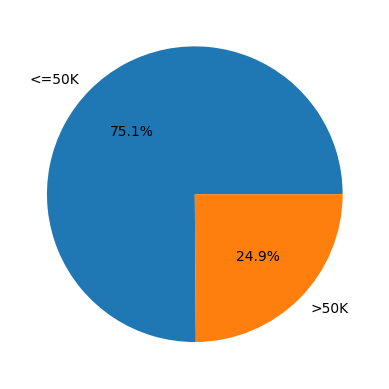

In [ ]:
# Primero se verifica la proporción del target
plt.figure(figsize=(6, 4))
plt.pie(df["income"].value_counts(), labels=df["income"].value_counts().index, autopct='%1.1f%%')

In [24]:
def plot_categorical_feature(df, feature, y_top_limit=None):
    plt.figure(figsize=(12,5))
    sns.countplot(data=df, x=feature, hue="income")
    plt.title
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.ylim(0, y_top_limit)  # Limitar el eje y si se indica un límite
    plt.title(f"Distribución de {feature} por ingreso (<=50K vs >50K)")
    plt.legend(title="Income")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

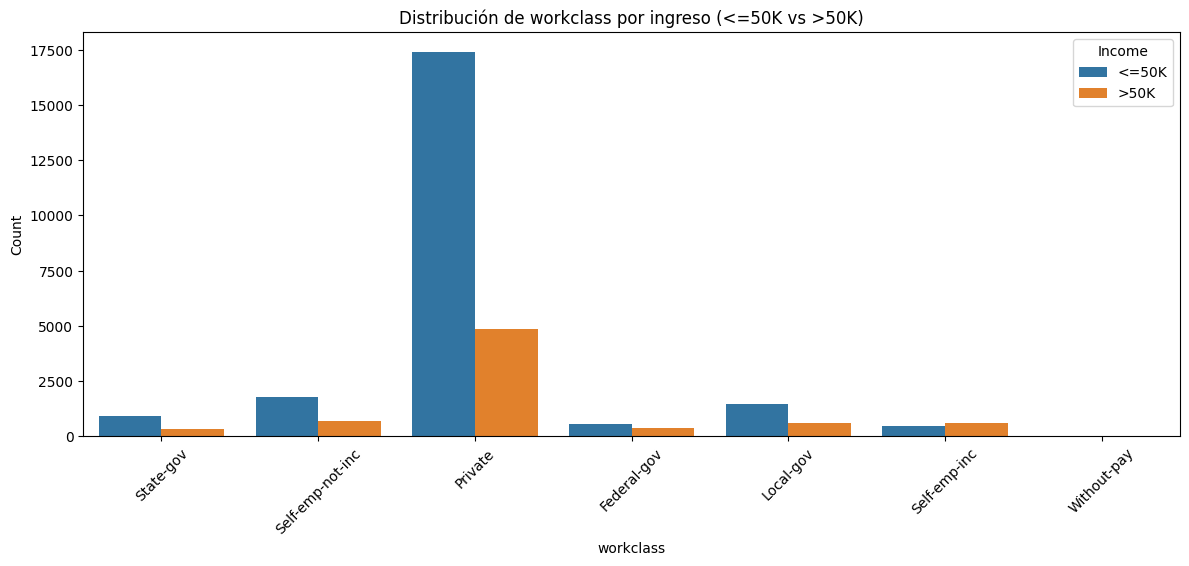

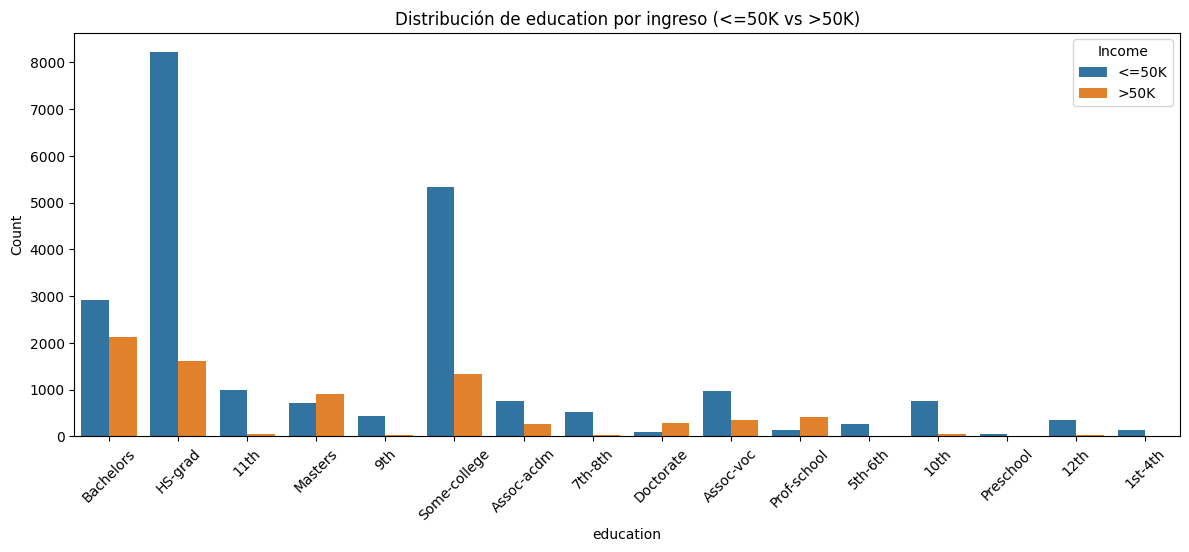

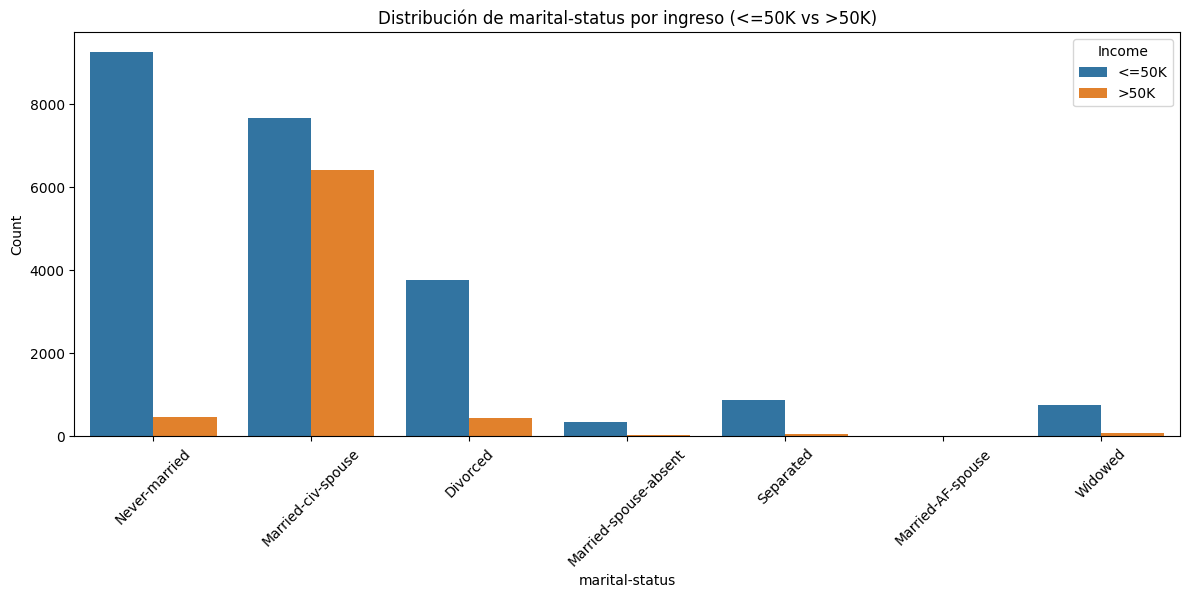

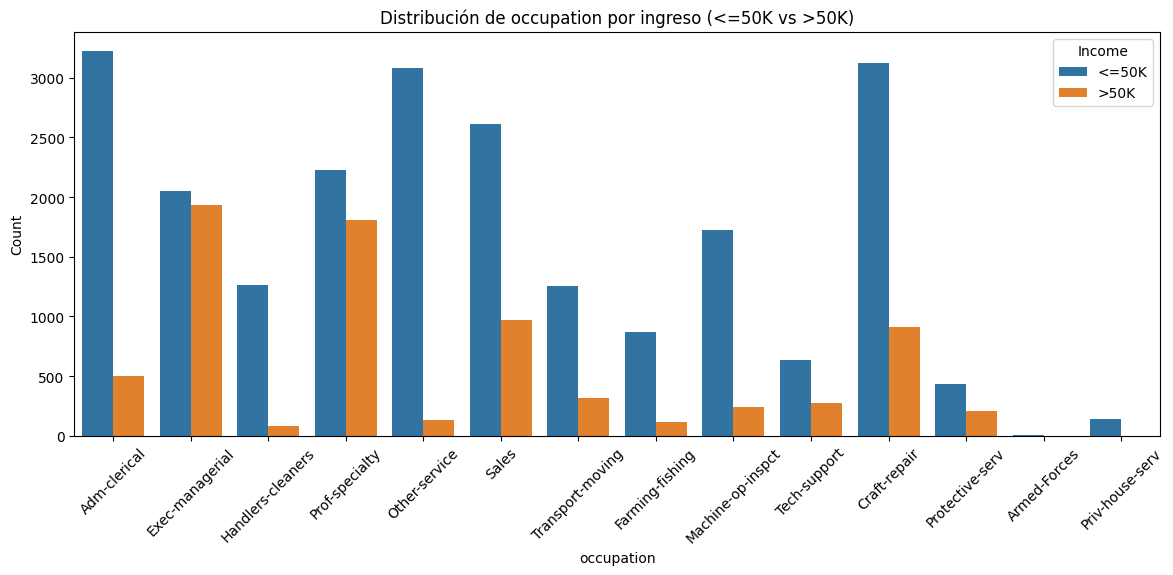

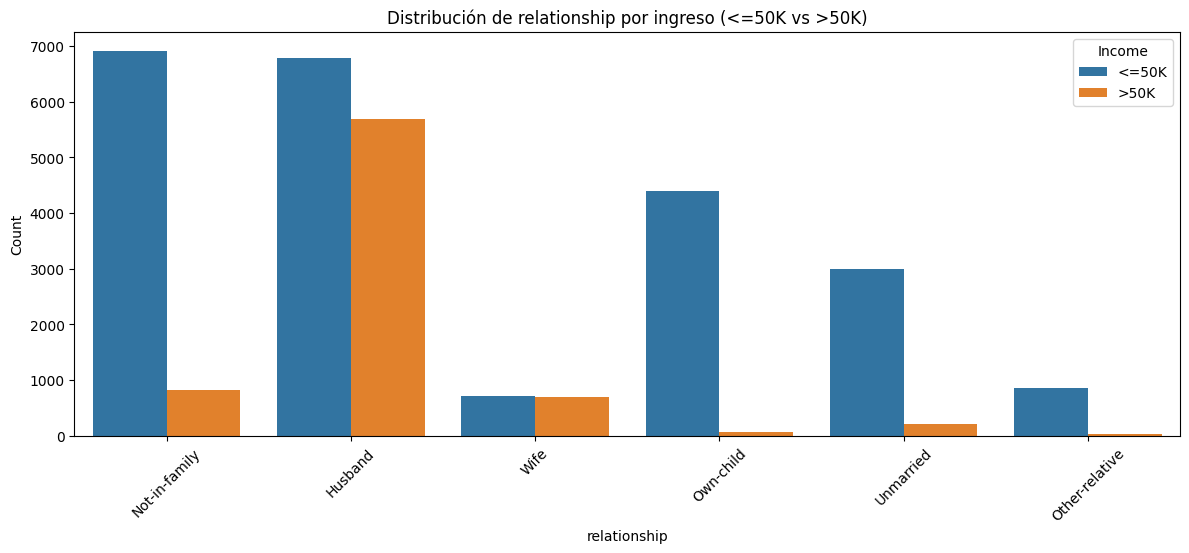

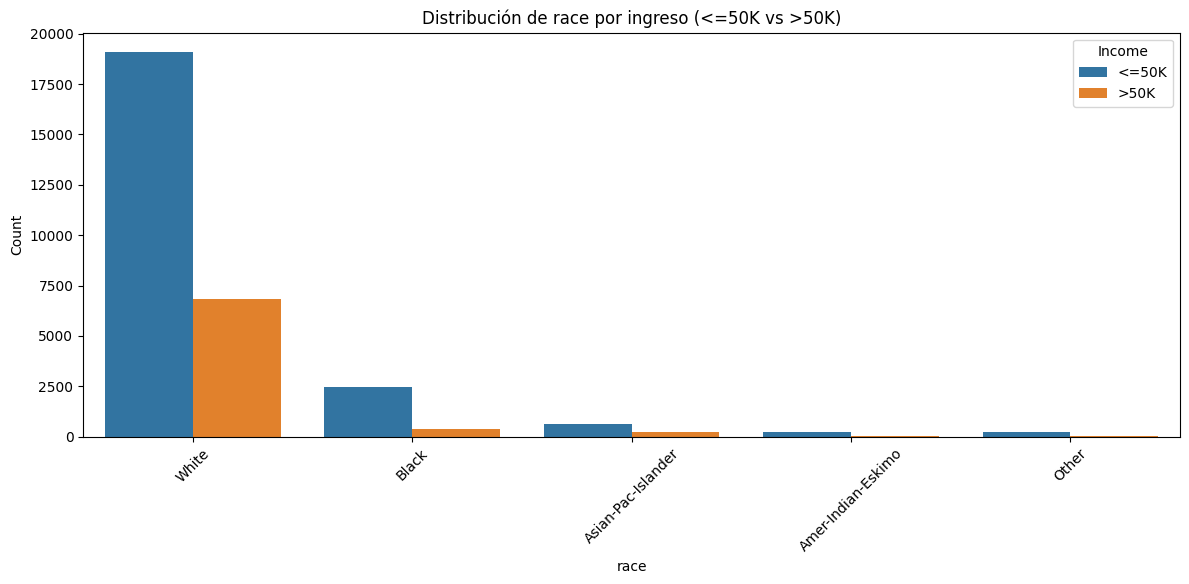

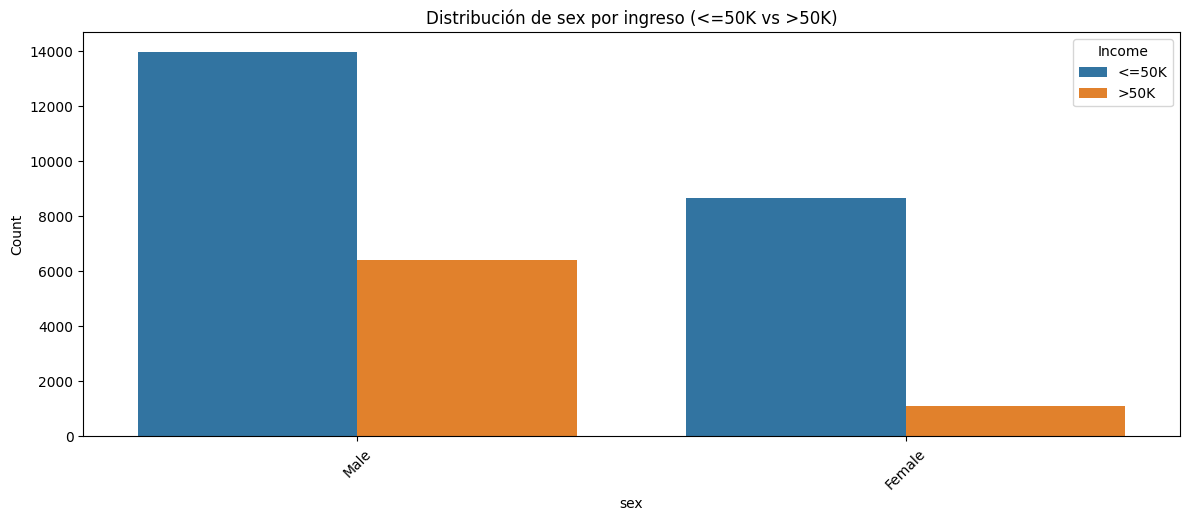

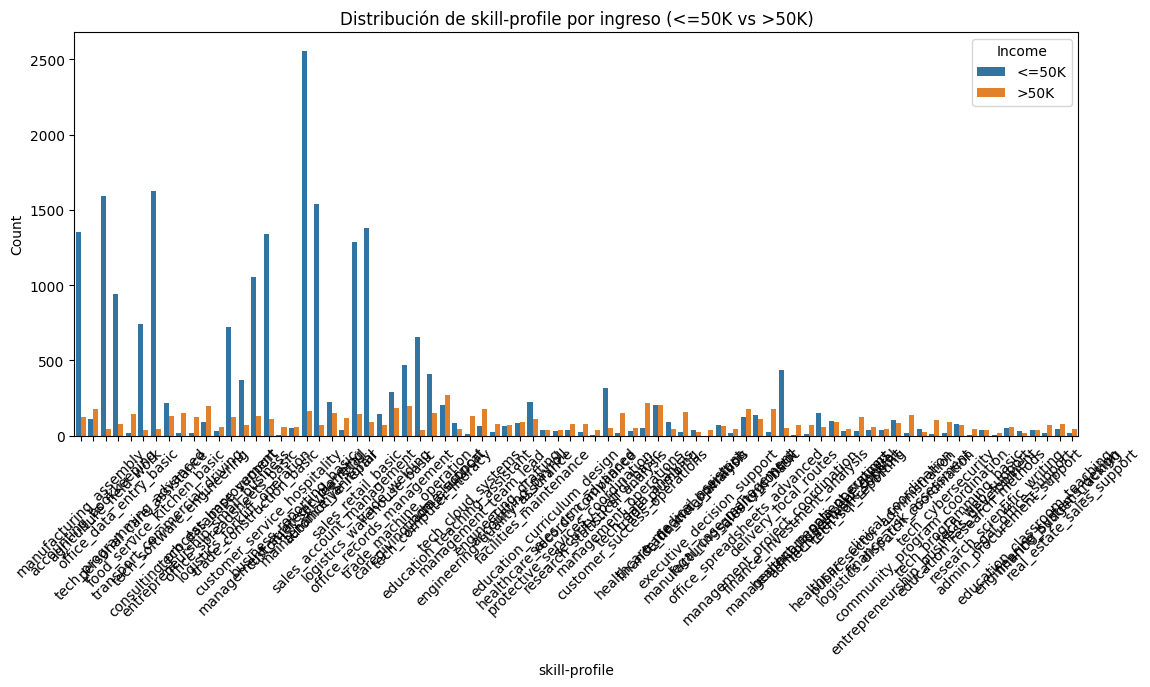

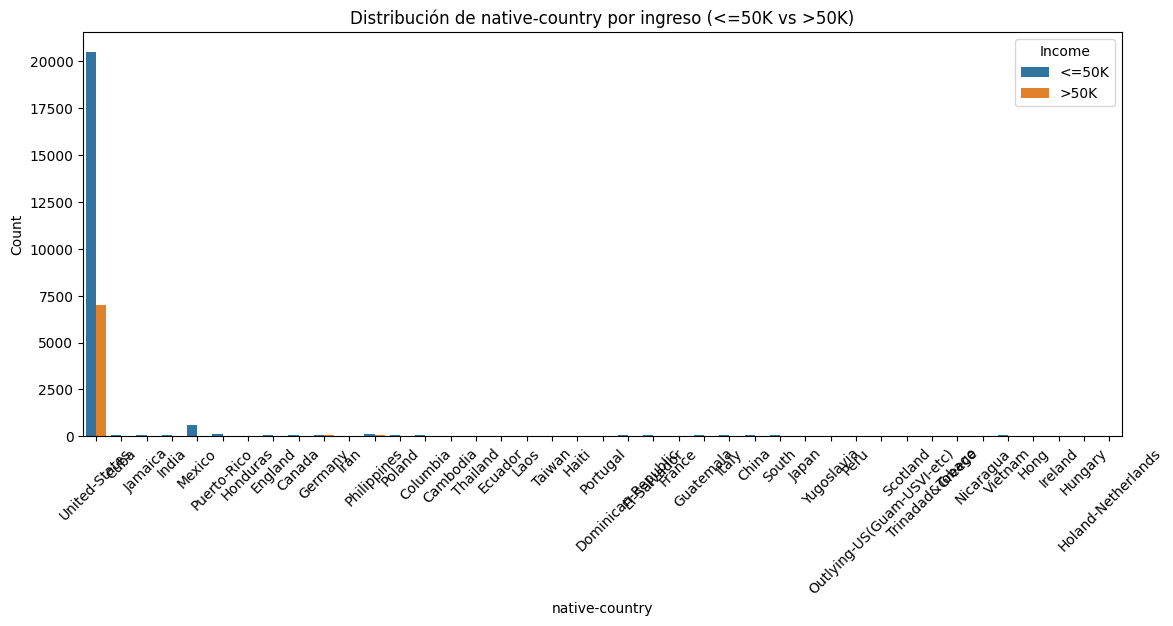

In [25]:
for feature in cat_features.columns:
    plot_categorical_feature(df, feature)

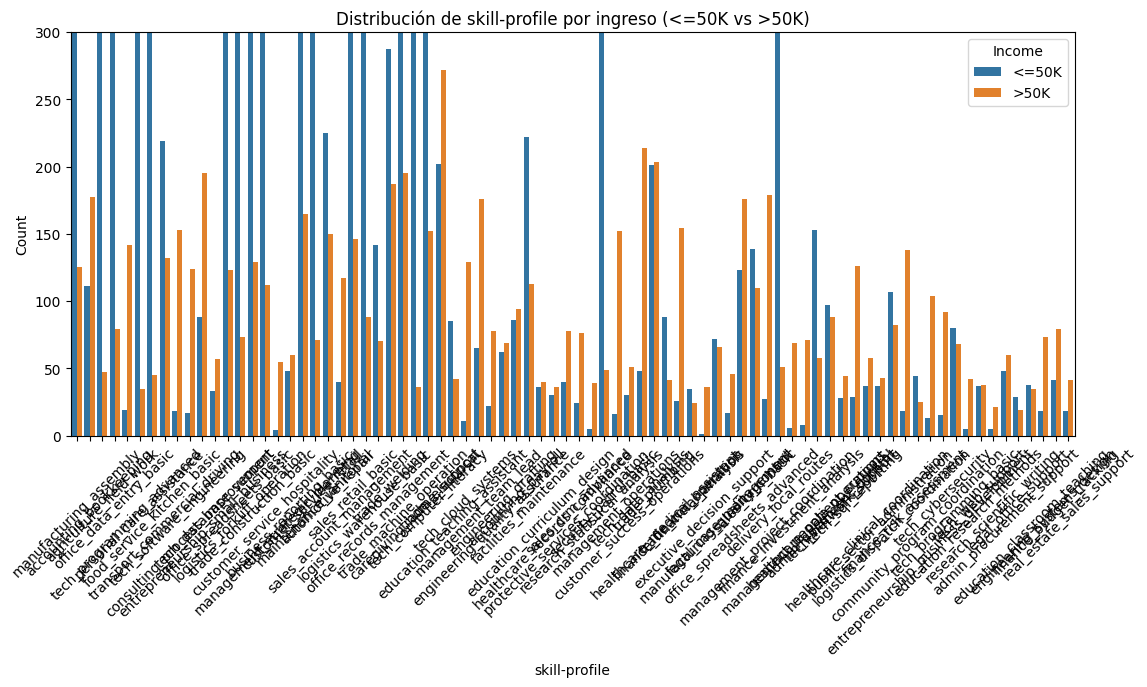

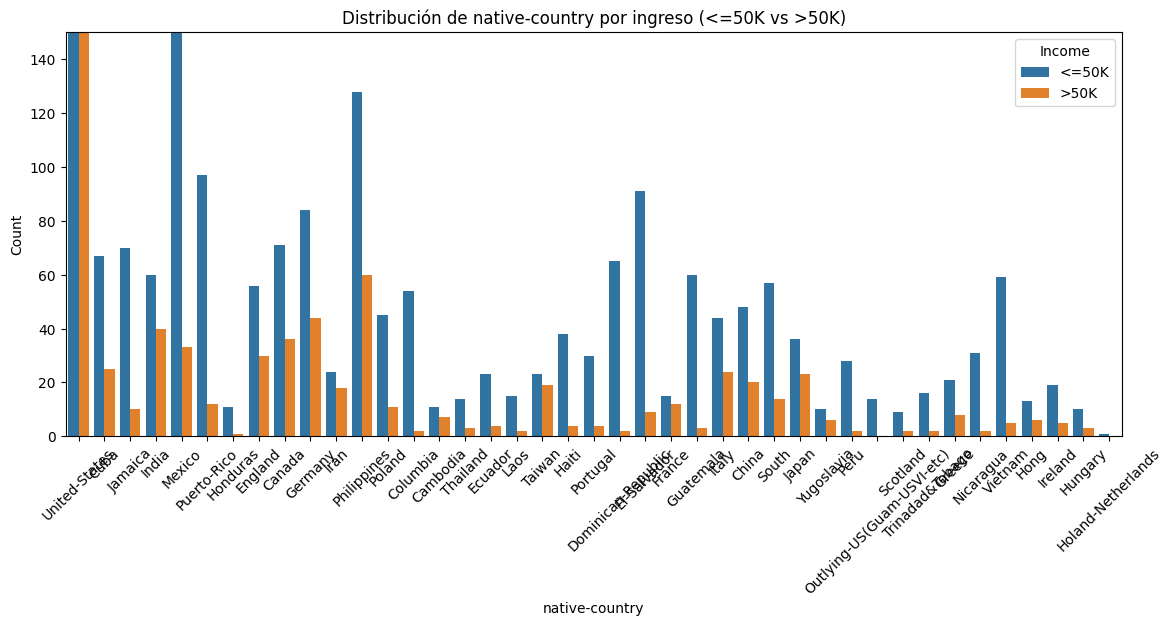

In [26]:
# Se vuelve a plotear las distribuciones de los features skill-profile
# y native-country limitando en el eje y.
plot_categorical_feature(df, "skill-profile", y_top_limit=300)
plot_categorical_feature(df, "native-country", y_top_limit=150)



In [42]:
def plot_numerical_feature(df, feature, y_top_limit=None):
    plt.figure(figsize=(12,5))
    sns.histplot(data=df, x=feature, hue="income", kde=True)
    plt.title(f"Distribución de {feature} por ingreso (<=50K vs >50K)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.ylim(0, y_top_limit)  # Limitar el eje y si se indica un límite
    plt.tight_layout()
    plt.show()

def plot_numerical_feature_boxplot(df, feature):
    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x="income", y=feature)
    plt.title(f"Boxplot de {feature} por ingreso (<=50K vs >50K)")
    plt.xlabel("Income")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

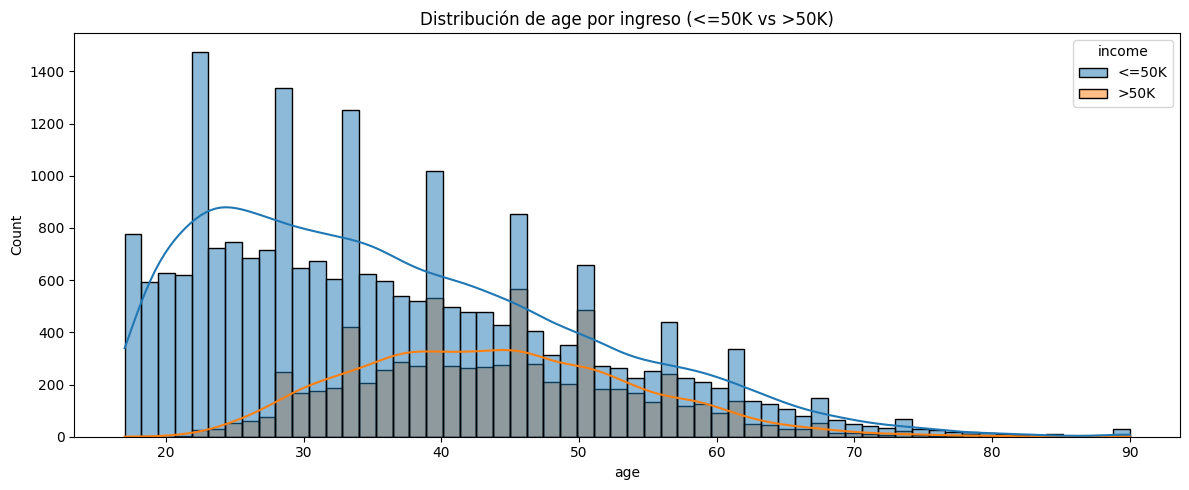

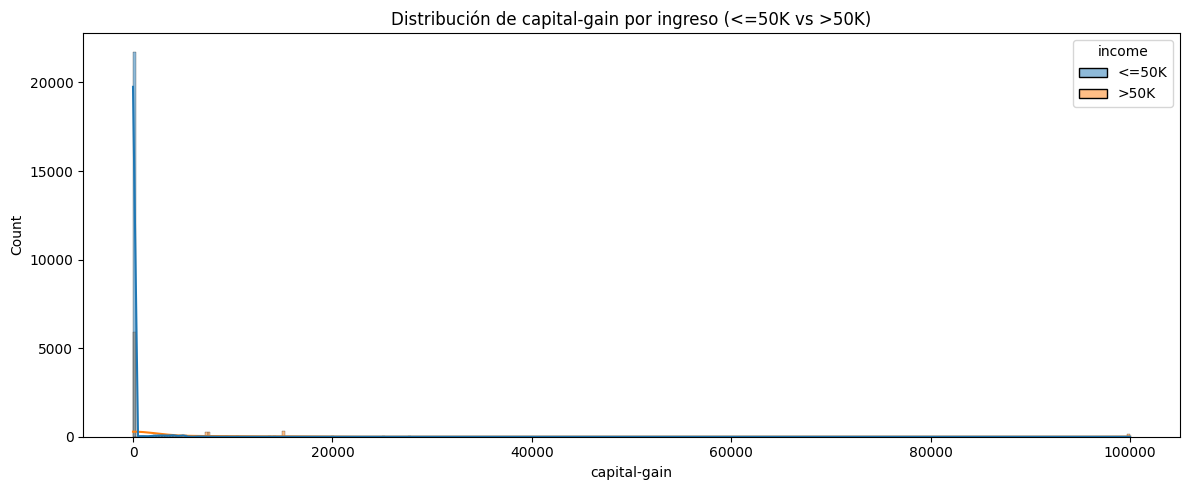

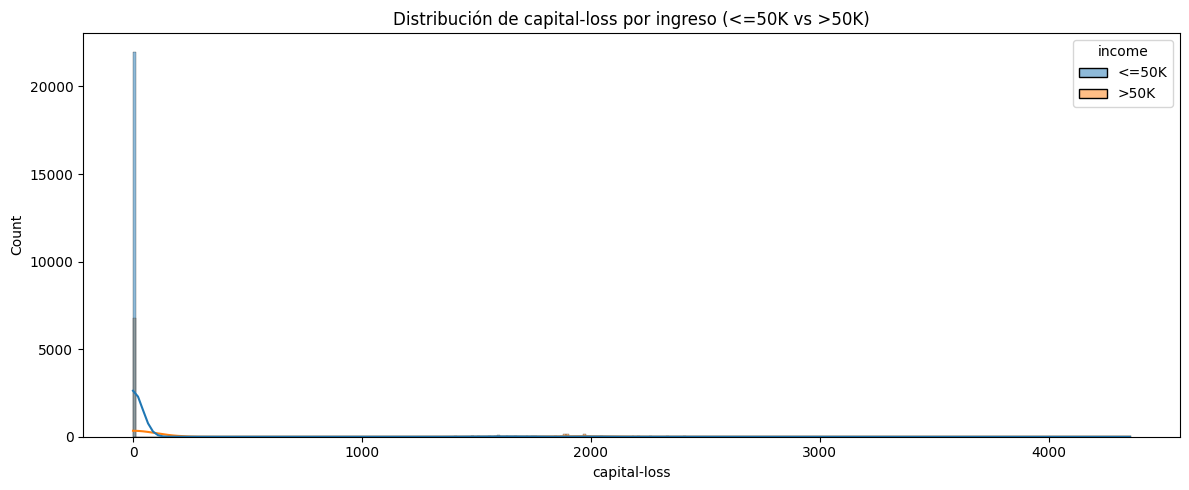

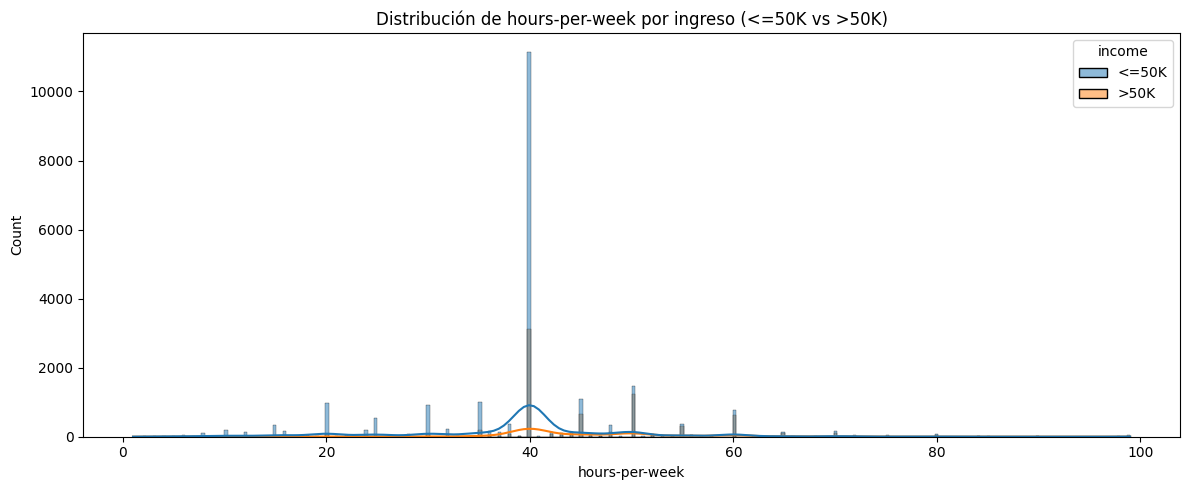

In [47]:
for feature in num_features.columns:
    plot_numerical_feature(df, feature)

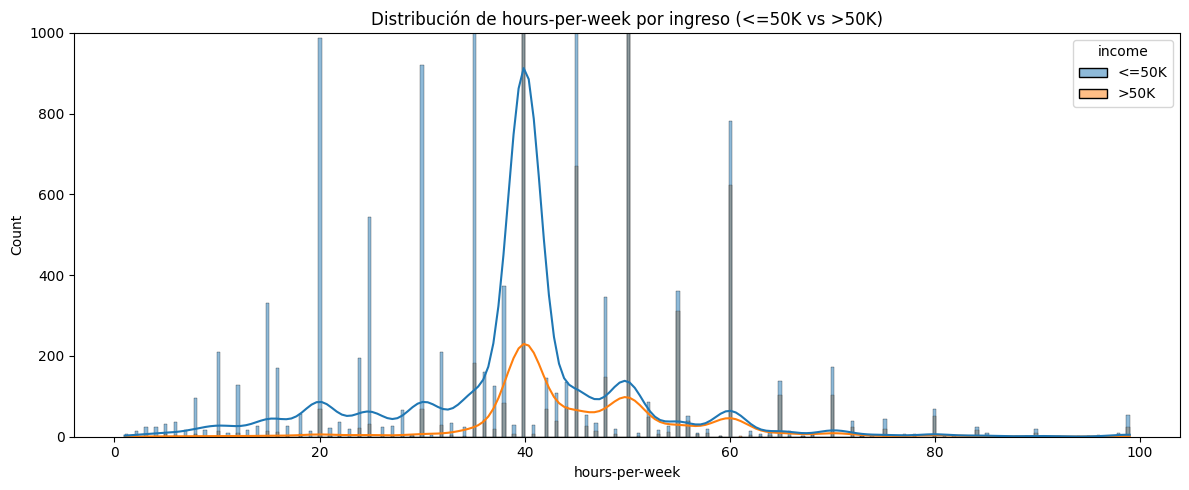

In [48]:
plot_numerical_feature(df, "hours-per-week", y_top_limit=1000)

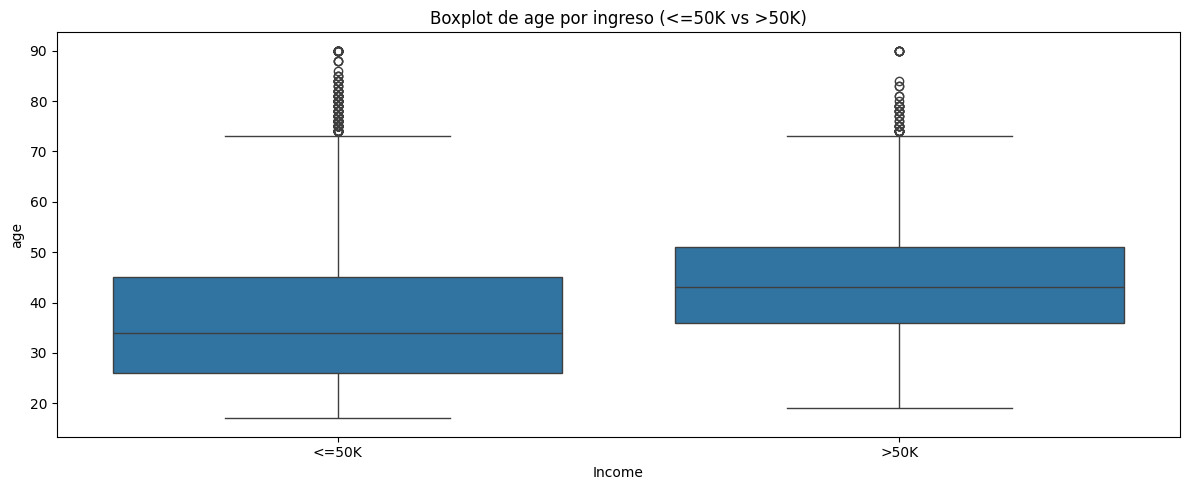

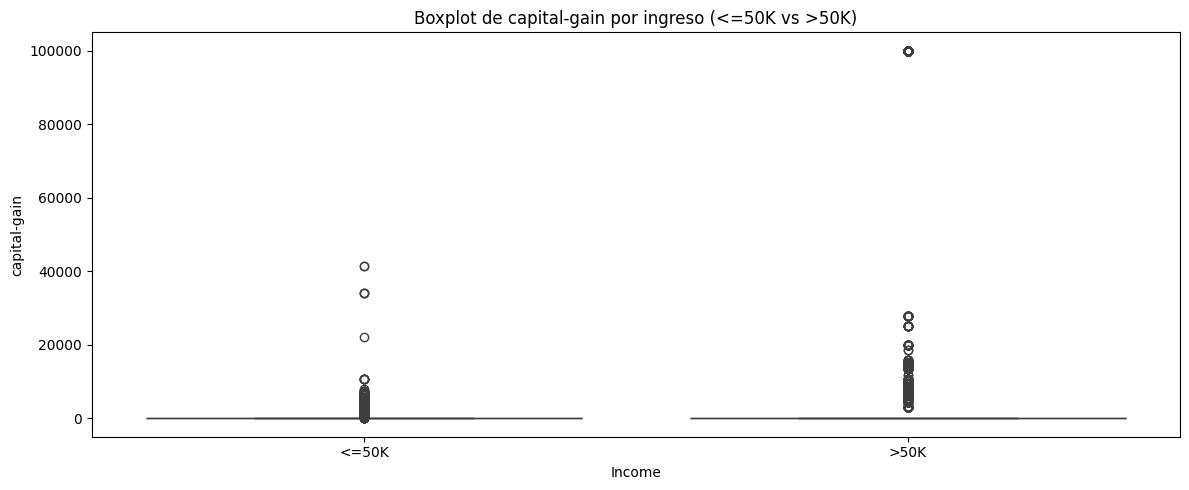

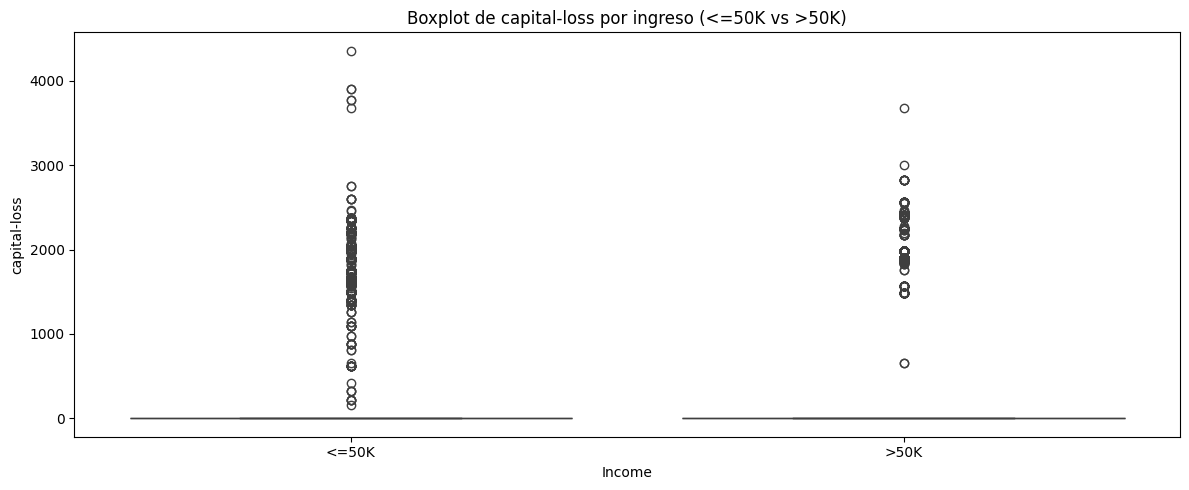

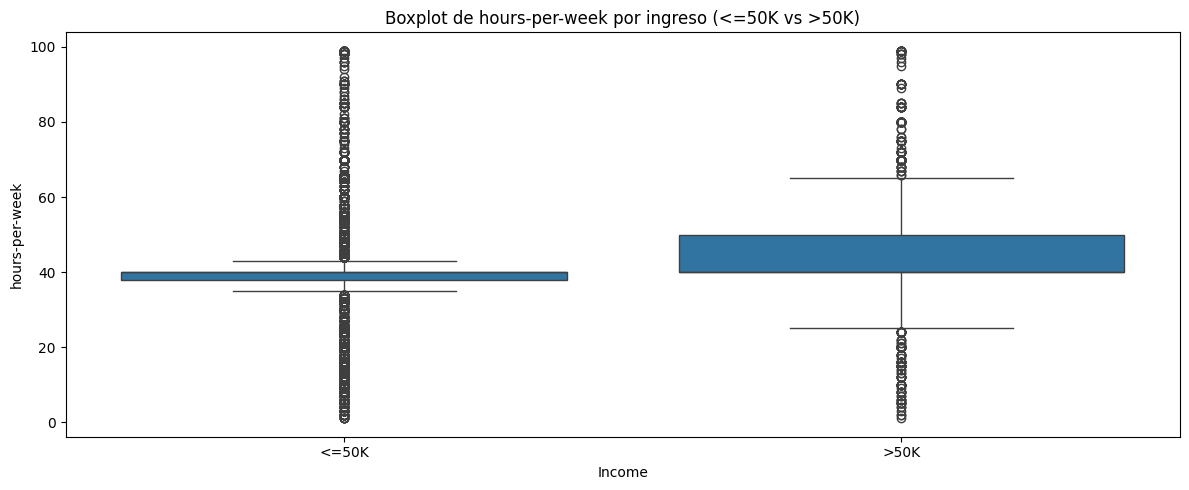

In [49]:
for feature in num_features.columns:
    plot_numerical_feature_boxplot(df, feature)

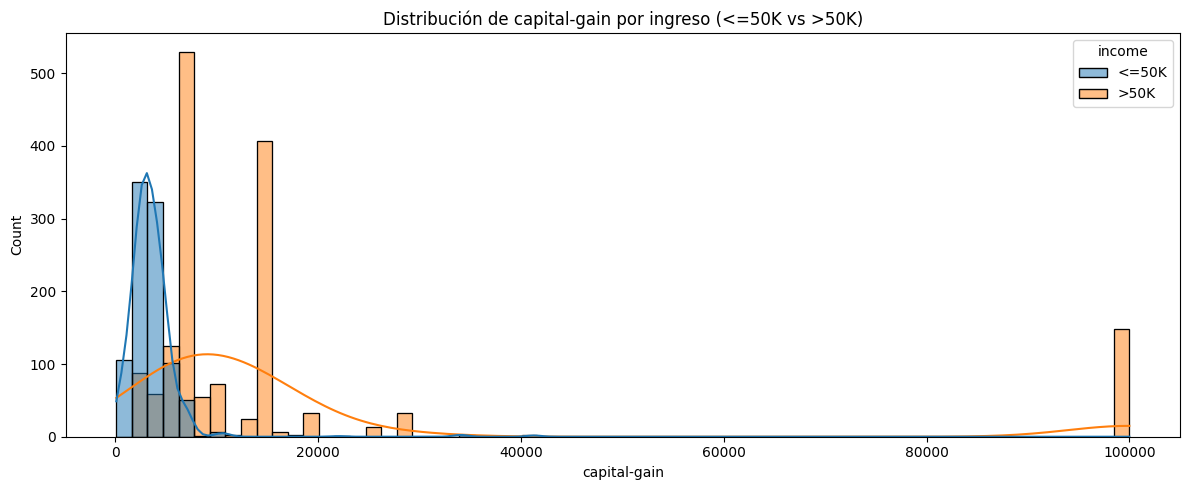

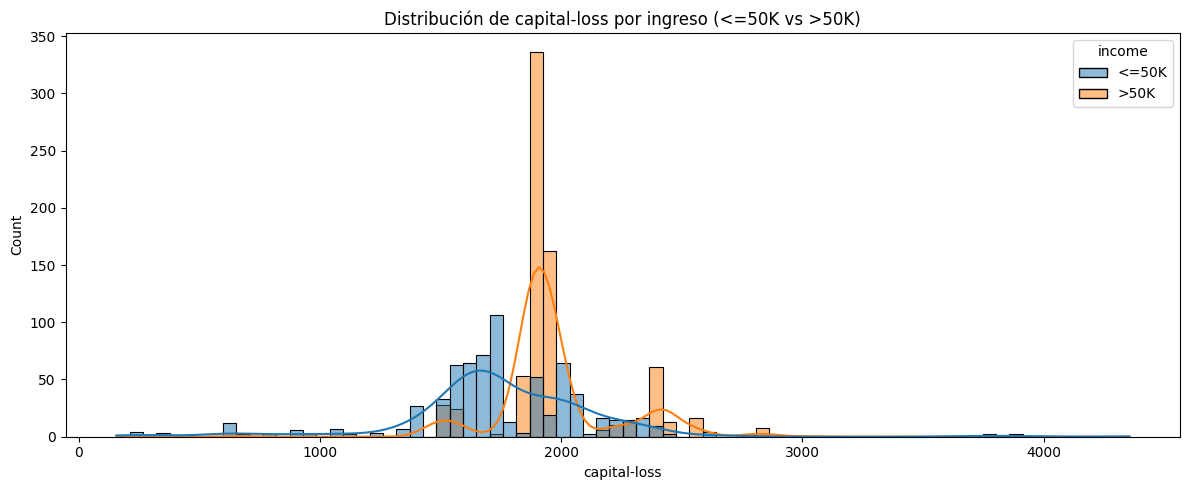

capital-gain tiene 2538 valores distintos a 0 (8.41%)
capital-loss tiene 1427 valores distintos a 0 (4.73%)


In [53]:
n_capital_gain_zero = df[df['capital-gain'] == 0].shape[0]
n_capital_loss_zero = df[df['capital-loss'] == 0].shape[0]

# Se filtran todos estos registros con 0 y se vuelven a graficar.
df_filtered_gain = df[(df['capital-gain'] != 0)]
df_filtered_loss = df[(df['capital-loss'] != 0)]
plot_numerical_feature(df_filtered_gain, "capital-gain")
plot_numerical_feature(df_filtered_loss, "capital-loss")

total_rows = df.shape[0]
print(f"capital-gain tiene {len(df_filtered_gain)} valores distintos a 0 ({len(df_filtered_gain)/total_rows*100:.2f}%)")
print(f"capital-loss tiene {len(df_filtered_loss)} valores distintos a 0 ({len(df_filtered_loss)/total_rows*100:.2f}%)")

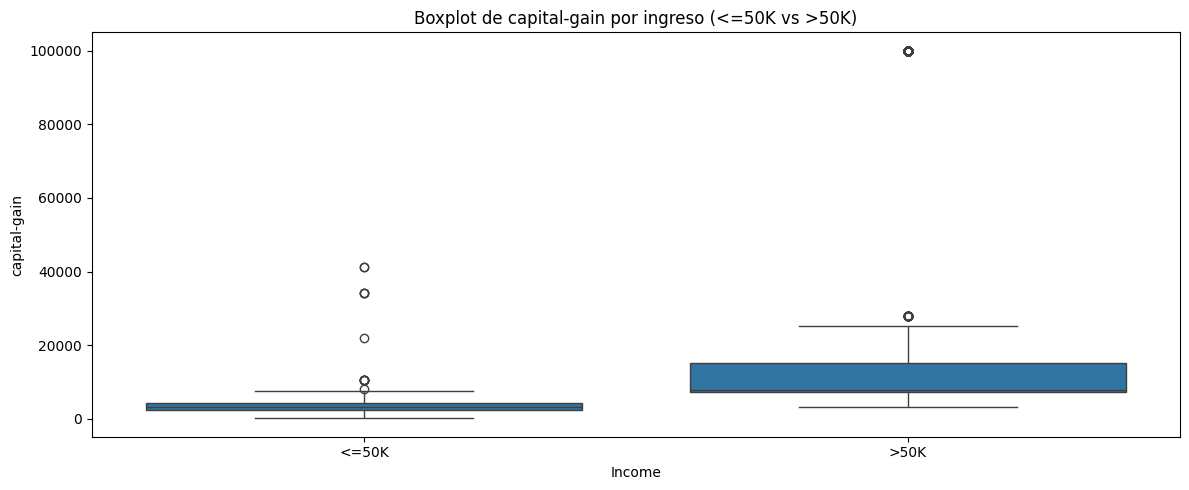

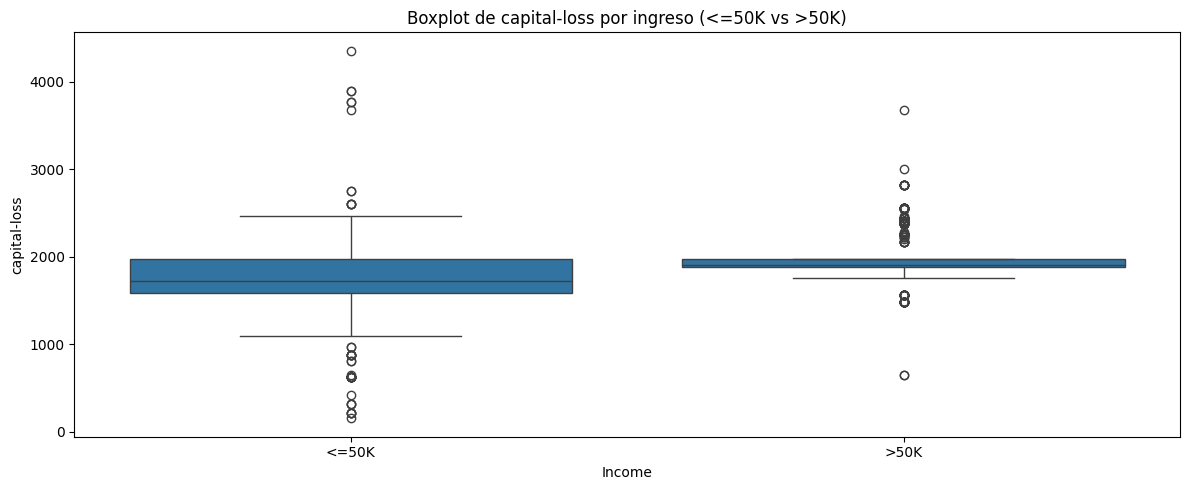

In [56]:
plot_numerical_feature_boxplot(df_filtered_gain, "capital-gain")
plot_numerical_feature_boxplot(df_filtered_loss, "capital-loss")

Se observa de manera generalizada que todos los features muestran una relación de sus valores con el target que puede influir en la predicciones. No hay valores nulos, pero sí existen outliers, principalmente en capital-gain y capital-loss, incluso analizándolo sin aquellos registros que tienen estos atributos en 0. Sin embargo, no se decide descartarlos en un principio.

Ahora, se analizan las variables categóricas a nivel cardinalidad, contexto y/o lógica interna para definir el mejor tipo de encoding para cada una.

In [ ]:
cat_features.nunique()

workclass          7
education         16
marital-status     7
occupation        14
relationship       6
race               5
sex                2
skill-profile     80
native-country    41
dtype: int64

: 

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.